In [1]:
!pip install opendatasets --quiet
import opendatasets as od
kaggleURL = "https://www.kaggle.com/datasets/"
od.download(kaggleURL + "masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  spirosh


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|████████████████████████████████████████████████████████████████████████████████| 149M/149M [00:00<00:00, 1.46GB/s]


In [4]:
!pip install seaborn --quiet

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from tqdm import tqdm

In [7]:
# ---- Configuration ----
ROOT_DATA_DIR = 'brain-tumor-mri-dataset' # Root of the new structure
TRAIN_DATA_DIR = os.path.join(ROOT_DATA_DIR, 'Training')
TEST_DATA_DIR = os.path.join(ROOT_DATA_DIR, 'Testing')

In [8]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE_SUPERVISED = 0.001
NUM_EPOCHS_SUPERVISED = 15
NUM_CLASSES = 4 # glioma, meningioma, notumor, pituitary

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"I am on {device}")

I am on cuda


In [10]:
supervised_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1), # Convert to grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalize for single channel
])

In [11]:
# Load the training and testing datasets directly
train_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=supervised_transform)
test_dataset = datasets.ImageFolder(root=TEST_DATA_DIR, transform=supervised_transform)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# Get class names for plotting later
class_names = train_dataset.classes

In [14]:
print(f"Supervised Training Samples: {len(train_dataset)}")
print(f"Supervised Test Samples: {len(test_dataset)}")
print(f"Classes: {class_names}")

Supervised Training Samples: 5712
Supervised Test Samples: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
# --- Supervised Model Definition (Multi-class CNN) ---
class TumorClassifier(nn.Module):
    def __init__(self, num_classes):
        super(TumorClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 16x64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32x32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 64x16x16
        )
        # Calculate flat features size: 64 * (IMAGE_SIZE/8) * (IMAGE_SIZE/8)
        self.classifier = nn.Sequential(
            nn.Linear(64 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes) # Multi-class output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

In [16]:
# --- Training Function ---
def train_supervised_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, class_names):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    print("\n--- Starting Supervised Training ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            images, labels = images.to(device), labels.to(device).long() # Labels should be long for CrossEntropyLoss

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1) # Get predicted class
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Test) "):
                images, labels = images.to(device), labels.to(device).long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_test_loss = test_loss / len(test_loader)
        test_accuracy = correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    print("\n--- Supervised Training Complete ---")
    # Final evaluation on test set
    final_test_accuracy = accuracy_score(all_labels, all_preds)
    final_confusion_matrix = confusion_matrix(all_labels, all_preds)
    print(f"\nFinal Supervised Test Accuracy: {final_test_accuracy:.4f}")
    print("Final Supervised Confusion Matrix:\n", final_confusion_matrix)

    return train_losses, test_losses, train_accuracies, test_accuracies, final_test_accuracy, final_confusion_matrix

In [17]:
# --- Run Supervised Learning ---
supervised_model = TumorClassifier(num_classes=NUM_CLASSES).to(device)
criterion_supervised = nn.CrossEntropyLoss() # For multi-class classification
optimizer_supervised = optim.Adam(supervised_model.parameters(), lr=LEARNING_RATE_SUPERVISED)

(sup_train_losses, sup_test_losses,
 sup_train_accuracies, sup_test_accuracies,
 final_sup_accuracy, final_sup_cm) = train_supervised_model(
    supervised_model, train_loader, test_loader,
    criterion_supervised, optimizer_supervised, NUM_EPOCHS_SUPERVISED, class_names
)


--- Starting Supervised Training ---


Epoch 1/15 (Test) : 100%|███████████████████████████████████████████████████████████████| 41/41 [00:04<00:00,  9.23it/s]


Epoch [1/15], Train Loss: 0.8000, Train Acc: 0.6789, Test Loss: 0.6159, Test Acc: 0.7506


Epoch 2/15 (Test) : 100%|███████████████████████████████████████████████████████████████| 41/41 [00:02<00:00, 15.55it/s]


Epoch [2/15], Train Loss: 0.4710, Train Acc: 0.8249, Test Loss: 0.5010, Test Acc: 0.7780


...

Epoch [13/15], Train Loss: 0.0701, Train Acc: 0.9744, Test Loss: 0.1461, Test Acc: 0.9619


Epoch 14/15 (Test) : 100%|██████████████████████████████████████████████████████████████| 41/41 [00:02<00:00, 14.66it/s]


Epoch [14/15], Train Loss: 0.0591, Train Acc: 0.9792, Test Loss: 0.1150, Test Acc: 0.9733


Epoch 15/15 (Test) : 100%|██████████████████████████████████████████████████████████████| 41/41 [00:02<00:00, 16.35it/s]


Epoch [15/15], Train Loss: 0.0497, Train Acc: 0.9800, Test Loss: 0.1236, Test Acc: 0.9626

--- Supervised Training Complete ---

Final Supervised Test Accuracy: 0.9626
Final Supervised Confusion Matrix:
 [[280  20   0   0]
 [ 16 283   1   6]
 [  0   4 401   0]
 [  1   1   0 298]]


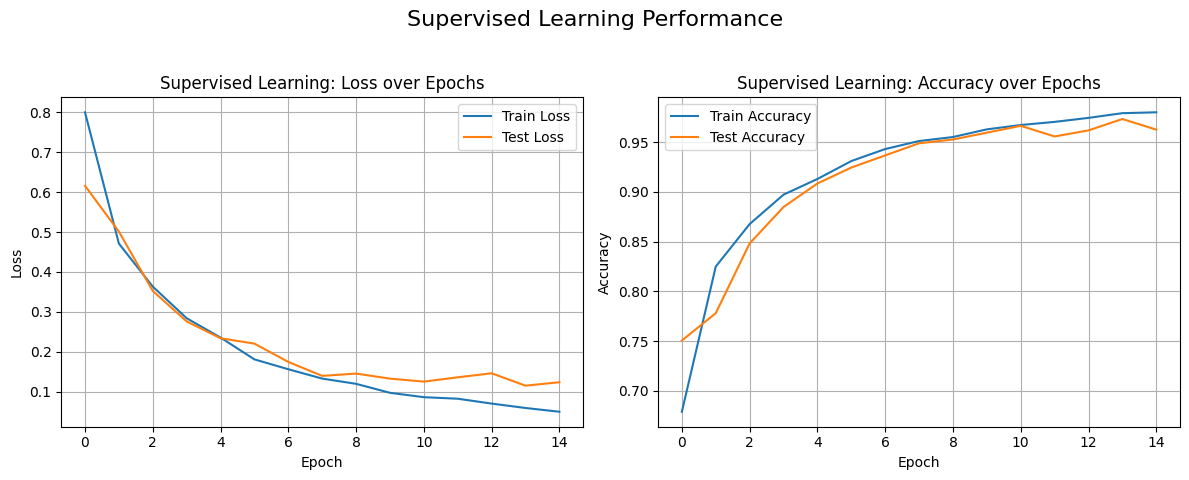

In [18]:
# --- Plotting Supervised Results ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sup_train_losses, label='Train Loss')
plt.plot(sup_test_losses, label='Test Loss')
plt.title('Supervised Learning: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sup_train_accuracies, label='Train Accuracy')
plt.plot(sup_test_accuracies, label='Test Accuracy')
plt.title('Supervised Learning: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Supervised Learning Performance', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

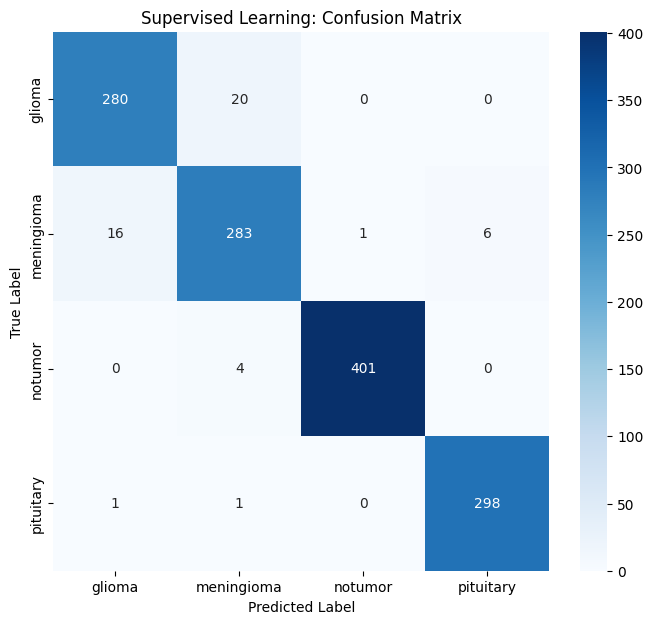

In [19]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 7)) # Adjust size for 4x4 matrix
sns.heatmap(final_sup_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Supervised Learning: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()